In [16]:
import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt
import time

from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from tqdm import tqdm
from sklearn.decomposition import PCA
from collections import defaultdict
import math

###############################################################################
# Arguments
###############################################################################
args = {
    "models": ["nlpaueb/sec-bert-base", "bert-base-uncased"],
    "datasets": [
        {
            "name": "yelp_review_full",
            "config": None,
            "split": "train",
            "text_column": "text",
        },
        {
            "name": "wikitext",
            "config": "wikitext-2-raw-v1",
            "split": "train",
            "text_column": "text",
        },
        {"name": "ag_news", "config": None, "split": "train", "text_column": "text"},
    ],
    "max_texts": 100,
    "batch_size": 64,
    "drift_strengths": [0.0, 0.25, 0.5, 0.75, 1.0],
    "pca_components": 2,
    "output_dir": "results_multidataset",
    "num_seeds": 1,
}
os.makedirs(args["output_dir"], exist_ok=True)


###############################################################################
# 1) Utility Functions
###############################################################################
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def batch_generator(data, batch_size=32):
    for i in range(0, len(data), batch_size):
        yield data[i : i + batch_size]


def extract_cls_embeddings(model, tokenizer, texts, device):
    encodings = tokenizer(
        texts, return_tensors="pt", padding=True, truncation=True, max_length=128
    )
    input_ids = encodings["input_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
    return cls_embeddings.cpu().numpy()


def introduce_gradual_drift(text_list, fraction_shuffle=0.5):
    new_texts = []
    for txt in text_list:
        words = txt.split()
        if len(words) < 2:
            new_texts.append(txt)
            continue
        k = int(len(words) * fraction_shuffle)
        if k < 1:
            new_texts.append(txt)
            continue
        indices = list(range(len(words)))
        random.shuffle(indices)
        shuffle_indices = indices[:k]
        to_shuffle = [words[i] for i in shuffle_indices]
        random.shuffle(to_shuffle)
        for i, idx in enumerate(shuffle_indices):
            words[idx] = to_shuffle[i]
        new_texts.append(" ".join(words))
    return new_texts


###############################################################################
# 2) Vector/Feature-Space Distance Functions
###############################################################################
def euclidean_distance(x, y):
    return np.sqrt(np.sum((x - y) ** 2))


def manhattan_distance(x, y):
    return np.sum(np.abs(x - y))


def minkowski_distance(x, y, p=3):
    return np.sum(np.abs(x - y) ** p) ** (1.0 / p)


def chebyshev_distance(x, y):
    return np.max(np.abs(x - y))


def canberra_distance(x, y):
    numerator = np.abs(x - y)
    denominator = np.abs(x) + np.abs(y) + 1e-12
    return np.sum(numerator / denominator)


DISTANCE_FUNCTIONS = {
    "euclidean": euclidean_distance,
    "manhattan": manhattan_distance,
    "minkowski": lambda u, v: minkowski_distance(u, v, p=3),
    "chebyshev": chebyshev_distance,
    "canberra": canberra_distance,
}


###############################################################################
# 3) EmbeddingTracker for Mahalanobis or simpler distances
###############################################################################
class EmbeddingTracker:
    def __init__(self, embedding_dim, alpha=0.01, distance_name="mahalanobis"):
        self.alpha = alpha
        self.distance_name = distance_name
        self.mean = np.zeros((embedding_dim,))
        self.count = 0
        self.cov = np.eye(embedding_dim)

    def update(self, embedding):
        if self.count == 0:
            self.mean = embedding
            if self.distance_name == "mahalanobis":
                self.cov = np.eye(len(embedding))
        else:
            self.mean = (1 - self.alpha) * self.mean + self.alpha * embedding
            if self.distance_name == "mahalanobis":
                diff = embedding - self.mean
                self.cov = (1 - self.alpha) * self.cov + self.alpha * np.outer(
                    diff, diff
                )
        self.count += 1

    def compute_distance(self, embedding):
        if self.distance_name == "mahalanobis":
            diff = embedding - self.mean
            cov_inv = np.linalg.pinv(self.cov)
            return np.sqrt(diff.T @ cov_inv @ diff)
        else:
            dist_fn = DISTANCE_FUNCTIONS[self.distance_name]
            return dist_fn(self.mean, embedding)


###############################################################################
# 4) Advanced KLL Implementation
###############################################################################


class GKSketch1D:
    def __init__(self, epsilon=0.01):
        self.epsilon = epsilon
        self.summary = []
        self.n = 0

    def update(self, x):
        self.n += 1
        if len(self.summary) == 0:
            self.summary.append([x, 1, 0])
            return
        pos = self._find_position(x)
        if pos == 0:
            delta_new = 0
        else:
            delta_new = self._allowed_error()
        self.summary.insert(pos, [x, 1, delta_new])
        self._compress()

    def _allowed_error(self):
        return math.floor(2 * self.epsilon * self.n)

    def _find_position(self, x):
        lo, hi = 0, len(self.summary)
        while lo < hi:
            mid = (lo + hi) // 2
            if self.summary[mid][0] < x:
                lo = mid + 1
            else:
                hi = mid
        return lo

    def _compress(self):
        allowed = self._allowed_error()
        merged = []
        merged.append(self.summary[0])
        for i in range(1, len(self.summary)):
            v_i, g_i, d_i = self.summary[i]
            v_m, g_m, d_m = merged[-1]
            if g_m + g_i + d_i <= allowed:
                merged[-1] = [v_i, g_m + g_i, d_m]
            else:
                merged.append(self.summary[i])
        self.summary = merged

    def merge(self, other):
        for bucket in other.summary:
            val, g, _ = bucket
            for _ in range(g):
                self.update(val)

    def query_quantile(self, phi):
        if not self.summary:
            return None
        rank_target = phi * self.n
        rank = 0
        for v, g, d in self.summary:
            rank += g
            if rank >= rank_target:
                return v
        return self.summary[-1][0]

    def approximate_mean(self):
        total = 0.0
        count = 0
        for val, g, _ in self.summary:
            total += val * g
            count += g
        if count == 0:
            return 0.0
        return total / count


class ReservoirSampler:
    def __init__(self):
        self.storage = []
        self.counter = 0

    def update(self, x):
        if len(self.storage) < 2:
            self.storage.append(x)
        else:
            self.counter += 1
            draw = random.randint(0, self.counter)
            if draw < 2:
                self.storage[draw] = x
        return None

    def merge(self, other):
        for val in other.storage:
            self.update(val)
        self.counter += other.counter

    def extract_all_values(self):
        return list(self.storage)

    def mean(self):
        if len(self.storage) == 0:
            return 0.0
        return np.mean(self.storage)


class KLLCompactor:
    def __init__(self, capacity=50):
        self.capacity = capacity
        self.items = []

    def update(self, x):
        self.items.append(x)
        if len(self.items) <= self.capacity:
            return None
        return self._compact()

    def merge(self, other):
        self.items.extend(other.items)
        if len(self.items) <= self.capacity:
            return None
        return self._compact()

    def _compact(self):
        self.items.sort()
        keep_odd = random.random() < 0.5
        survivors = []
        for i, val in enumerate(self.items):
            if keep_odd:
                if i % 2 == 1:
                    survivors.append(val)
            else:
                if i % 2 == 0:
                    survivors.append(val)
        self.items = survivors
        if len(self.items) <= self.capacity:
            return None
        overflow = self.items
        self.items = []
        return overflow

    def extract_all_values(self):
        return list(self.items)

    def reconstruct_with_count(self):
        return (list(self.items), len(self.items))


class KLLSketchAdvanced1D:
    def __init__(self, base_capacity=50, c=0.75, delta=1e-3, epsilon_gk=0.01):
        self.base_capacity = base_capacity
        self.c = c
        self.delta = delta
        self.epsilon_gk = epsilon_gk
        self.levels = []
        self.top_s = max(1, int(math.ceil(math.log2(max(2, 1.0 / self.delta)))))

    def update(self, x):
        if not self.levels:
            self.levels.append(self._create_level(0))
        self._add_to_level(0, x)

    def merge(self, other):
        max_len = max(len(self.levels), len(other.levels))
        for lvl in range(max_len):
            if lvl >= len(self.levels):
                self.levels.append(self._create_level(lvl))
            if lvl >= len(other.levels):
                continue
            self._merge_levels(lvl, other.levels[lvl])

    def _create_level(self, lvl_idx):
        H_guess = lvl_idx + self.top_s + 3
        if (H_guess - lvl_idx) <= self.top_s:
            return GKSketch1D(epsilon=self.epsilon_gk)
        else:
            cap = max(
                2,
                int(
                    math.floor(self.base_capacity * (self.c ** (H_guess - 1 - lvl_idx)))
                ),
            )
            if cap <= 2:
                return ReservoirSampler()
            else:
                return KLLCompactor(capacity=cap)

    def _add_to_level(self, lvl_idx, x):
        if lvl_idx >= len(self.levels):
            self.levels.append(self._create_level(lvl_idx))
        ds = self.levels[lvl_idx]
        if isinstance(ds, GKSketch1D):
            ds.update(x)
            return
        if isinstance(ds, ReservoirSampler):
            ds.update(x)
            return
        overflow_items = ds.update(x)
        if overflow_items is not None:
            nxt = lvl_idx + 1
            for val_up in overflow_items:
                self._add_to_level(nxt, val_up)

    def _merge_levels(self, lvl_idx, other_ds):
        if lvl_idx >= len(self.levels):
            self.levels.append(self._create_level(lvl_idx))
        ds = self.levels[lvl_idx]
        if isinstance(ds, GKSketch1D) and isinstance(other_ds, GKSketch1D):
            ds.merge(other_ds)
            return
        elif isinstance(ds, ReservoirSampler) and isinstance(
            other_ds, ReservoirSampler
        ):
            ds.merge(other_ds)
            return
        elif isinstance(ds, KLLCompactor) and isinstance(other_ds, KLLCompactor):
            overflow = ds.merge(other_ds)
            if overflow is not None:
                for val_up in overflow:
                    self._add_to_level(lvl_idx + 1, val_up)
            return
        else:
            for val in other_ds.extract_all_values():
                self._add_to_level(lvl_idx, val)

    def approximate_mean(self):
        total_sum = 0.0
        total_weight = 0.0
        for lvl_idx, ds in enumerate(self.levels):
            if isinstance(ds, GKSketch1D):
                mval = ds.approximate_mean()
                w = 2.0**lvl_idx
                total_sum += mval * w
                total_weight += w
            elif isinstance(ds, ReservoirSampler):
                mval = ds.mean()
                w = 2.0**lvl_idx
                total_sum += mval * w
                total_weight += w
            else:
                val_list, val_count = ds.reconstruct_with_count()
                sum_ = sum(val_list)
                w = 2.0**lvl_idx
                total_sum += sum_ * w
                total_weight += w * val_count
        if total_weight == 0:
            return 0.0
        return total_sum / total_weight


###############################################################################
# 5) KLL2DTrackerAdvanced
###############################################################################
class KLL2DTrackerAdvanced:
    def __init__(
        self,
        base_capacity=200,
        c=0.75,
        delta=1e-3,
        alpha=0.01,
        distance_name="mahalanobis",
        epsilon_gk=0.01,
    ):
        self.base_capacity = base_capacity
        self.c = c
        self.delta = delta
        self.alpha = alpha
        self.distance_name = distance_name
        self.epsilon_gk = epsilon_gk
        self.dim0 = None
        self.dim1 = None
        self.kll_dim0 = None
        self.kll_dim1 = None
        self.mean_2d = np.zeros((2,))
        self.cov_2d = np.eye(2)
        self.count = 0

    def fit_baseline(self, baseline_embs):
        var_per_dim = np.var(baseline_embs, axis=0)
        top2_dims = np.argsort(var_per_dim)[-2:]
        self.dim0 = top2_dims[0]
        self.dim1 = top2_dims[1]
        self.kll_dim0 = KLLSketchAdvanced1D(
            base_capacity=self.base_capacity,
            c=self.c,
            delta=self.delta,
            epsilon_gk=self.epsilon_gk,
        )
        self.kll_dim1 = KLLSketchAdvanced1D(
            base_capacity=self.base_capacity,
            c=self.c,
            delta=self.delta,
            epsilon_gk=self.epsilon_gk,
        )
        for vec in baseline_embs:
            self.kll_dim0.update(vec[self.dim0])
            self.kll_dim1.update(vec[self.dim1])
        m0 = self.kll_dim0.approximate_mean()
        m1 = self.kll_dim1.approximate_mean()
        self.mean_2d = np.array([m0, m1])
        self.count = baseline_embs.shape[0]

    def update_stream(self, embs_batch):
        for vec in embs_batch:
            self.kll_dim0.update(vec[self.dim0])
            self.kll_dim1.update(vec[self.dim1])
            m0 = self.kll_dim0.approximate_mean()
            m1 = self.kll_dim1.approximate_mean()
            if self.count == 0:
                self.mean_2d = np.array([m0, m1])
            else:
                self.mean_2d = (1 - self.alpha) * self.mean_2d + self.alpha * np.array(
                    [m0, m1]
                )
            if self.distance_name == "mahalanobis":
                diff_2d = np.array([m0, m1]) - self.mean_2d
                self.cov_2d = (1 - self.alpha) * self.cov_2d + self.alpha * np.outer(
                    diff_2d, diff_2d
                )
            self.count += 1

    def compute_distance(self):
        m0 = self.kll_dim0.approximate_mean()
        m1 = self.kll_dim1.approximate_mean()
        current_vec = np.array([m0, m1])
        if self.distance_name == "mahalanobis":
            diff = current_vec - self.mean_2d
            cov_inv = np.linalg.pinv(self.cov_2d)
            return np.sqrt(diff.T @ cov_inv @ diff)
        else:
            dist_fn = DISTANCE_FUNCTIONS[self.distance_name]
            return dist_fn(self.mean_2d, current_vec)


###############################################################################
# 6) Main Script
###############################################################################


def collect_data_single_seed(seed):
    set_seed(seed)
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
    print(f"[Seed={seed}] Using device:", device)

    results = defaultdict(list)

    for dataset_info in args["datasets"]:
        dataset_name = dataset_info["name"]
        dataset_config = dataset_info["config"]
        dataset_split = dataset_info["split"]
        text_col = dataset_info["text_column"]

        print(f"[Seed={seed}] === Loading dataset: {dataset_name} ===")
        ds = load_dataset(dataset_name, dataset_config, split=dataset_split)
        texts = list(ds[text_col])
        random.shuffle(texts)
        if args["max_texts"] > 0 and len(texts) > args["max_texts"]:
            texts = texts[: args["max_texts"]]

        half_point = len(texts) // 2
        baseline_texts = texts[:half_point]
        drift_texts = texts[half_point:]

        for model_name in args["models"]:
            print(f"[Seed={seed}] --- Using Model: {model_name} ---")
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            model = AutoModel.from_pretrained(model_name).to(device)
            model.eval()

            baseline_embs = []
            for b in batch_generator(baseline_texts, args["batch_size"]):
                emb_b = extract_cls_embeddings(model, tokenizer, b, device)
                baseline_embs.append(emb_b)
            baseline_embs = np.concatenate(baseline_embs, axis=0)

            pca = PCA(n_components=args["pca_components"])
            pca.fit(baseline_embs)

            kll_tracker_adv = KLL2DTrackerAdvanced(
                base_capacity=200,
                c=0.75,
                delta=1e-3,
                alpha=0.01,
                distance_name="mahalanobis",
                epsilon_gk=0.01,
            )
            kll_tracker_adv.fit_baseline(baseline_embs)

            key = (dataset_name, model_name)
            all_distance_names = ["mahalanobis"] + list(DISTANCE_FUNCTIONS.keys())

            for distance_name in all_distance_names:
                for drift_strength in args["drift_strengths"]:
                    drifted_texts = introduce_gradual_drift(
                        drift_texts, fraction_shuffle=drift_strength
                    )
                    test_texts = baseline_texts + drifted_texts

                    embedding_dim_no_pca = baseline_embs.shape[1]
                    tracker_no_pca = EmbeddingTracker(
                        embedding_dim_no_pca, alpha=0.01, distance_name=distance_name
                    )
                    distance_scores_no_pca = []
                    time_overhead_no_pca = []

                    for batch in batch_generator(baseline_texts, args["batch_size"]):
                        emb = extract_cls_embeddings(model, tokenizer, batch, device)
                        mean_emb = emb.mean(axis=0)
                        tracker_no_pca.update(mean_emb)

                    start_time_no_pca = time.time()
                    for batch in tqdm(
                        batch_generator(test_texts, args["batch_size"]), leave=False
                    ):
                        emb = extract_cls_embeddings(model, tokenizer, batch, device)
                        mean_emb = emb.mean(axis=0)
                        overhead_start = time.time()
                        dist = tracker_no_pca.compute_distance(mean_emb)
                        overhead_end = time.time()
                        distance_scores_no_pca.append(dist)
                        time_overhead_no_pca.append(overhead_end - overhead_start)
                        tracker_no_pca.update(mean_emb)
                    end_time_no_pca = time.time()

                    final_dist_no_pca = (
                        distance_scores_no_pca[-1] if distance_scores_no_pca else 0.0
                    )
                    time_no_pca = end_time_no_pca - start_time_no_pca
                    avg_overhead_no_pca = np.mean(time_overhead_no_pca)

                    embedding_dim_pca = args["pca_components"]
                    tracker_pca = EmbeddingTracker(
                        embedding_dim_pca, alpha=0.01, distance_name=distance_name
                    )
                    distance_scores_pca = []
                    time_overhead_pca = []

                    for batch in batch_generator(baseline_texts, args["batch_size"]):
                        emb = extract_cls_embeddings(model, tokenizer, batch, device)
                        emb_pca = pca.transform(emb)
                        mean_emb = emb_pca.mean(axis=0)
                        tracker_pca.update(mean_emb)

                    start_time_pca = time.time()
                    for batch in tqdm(
                        batch_generator(test_texts, args["batch_size"]), leave=False
                    ):
                        emb = extract_cls_embeddings(model, tokenizer, batch, device)
                        emb_pca = pca.transform(emb)
                        overhead_start = time.time()
                        dist = tracker_pca.compute_distance(emb_pca.mean(axis=0))
                        overhead_end = time.time()
                        distance_scores_pca.append(dist)
                        time_overhead_pca.append(overhead_end - overhead_start)
                        tracker_pca.update(emb_pca.mean(axis=0))
                    end_time_pca = time.time()

                    final_dist_pca = (
                        distance_scores_pca[-1] if distance_scores_pca else 0.0
                    )
                    time_pca = end_time_pca - start_time_pca
                    avg_overhead_pca = np.mean(time_overhead_pca)

                    kll_tracker_adv2 = KLL2DTrackerAdvanced(
                        base_capacity=200,
                        c=0.75,
                        delta=1e-3,
                        alpha=0.01,
                        distance_name=distance_name,
                        epsilon_gk=0.01,
                    )
                    kll_tracker_adv2.fit_baseline(baseline_embs)

                    distance_scores_kll = []
                    time_overhead_kll = []

                    start_time_kll = time.time()
                    for batch in tqdm(
                        batch_generator(test_texts, args["batch_size"]), leave=False
                    ):
                        emb = extract_cls_embeddings(model, tokenizer, batch, device)
                        overhead_start = time.time()
                        kll_tracker_adv2.update_stream(emb)
                        dist_kll = kll_tracker_adv2.compute_distance()
                        overhead_end = time.time()
                        distance_scores_kll.append(dist_kll)
                        time_overhead_kll.append(overhead_end - overhead_start)
                    end_time_kll = time.time()

                    final_dist_kll = (
                        distance_scores_kll[-1] if distance_scores_kll else 0.0
                    )
                    time_kll = end_time_kll - start_time_kll
                    avg_overhead_kll = np.mean(time_overhead_kll)

                    results[key].append(
                        {
                            "distance_name": distance_name,
                            "drift_strength": drift_strength,
                            "method": "normal",
                            "final_similarity": final_dist_no_pca,
                            "time_taken": time_no_pca,
                            "avg_overhead": avg_overhead_no_pca,
                            "seed": seed,
                        }
                    )
                    results[key].append(
                        {
                            "distance_name": distance_name,
                            "drift_strength": drift_strength,
                            "method": "pca2",
                            "final_similarity": final_dist_pca,
                            "time_taken": time_pca,
                            "avg_overhead": avg_overhead_pca,
                            "seed": seed,
                        }
                    )
                    results[key].append(
                        {
                            "distance_name": distance_name,
                            "drift_strength": drift_strength,
                            "method": "kll2d",
                            "final_similarity": final_dist_kll,
                            "time_taken": time_kll,
                            "avg_overhead": avg_overhead_kll,
                            "seed": seed,
                        }
                    )

    return results


def collect_data_multiple_seeds():
    all_results = defaultdict(list)
    for seed in range(args["num_seeds"]):
        seed_results = collect_data_single_seed(seed)
        for key, records in seed_results.items():
            all_results[key].extend(records)
    print("\nAll seeds complete!")
    return all_results


all_results = collect_data_multiple_seeds()

[Seed=0] Using device: mps
[Seed=0] === Loading dataset: yelp_review_full ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---


[Seed=0] --- Using Model: bert-base-uncased ---


[Seed=0] === Loading dataset: wikitext ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---


[Seed=0] --- Using Model: bert-base-uncased ---


[Seed=0] === Loading dataset: ag_news ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---


[Seed=0] --- Using Model: bert-base-uncased ---



All seeds complete!


In [17]:
def plot_overhead_bar_aggregated(summary_overhead, output_csv_path):
    """
    Create a grouped bar chart of overhead, aggregated across all
    Datasets, Models, and Drift Strengths, using a log scale.
    Save the results to a CSV file.
    """
    # We now group by (distance_name, method) instead of (distance_name, pca).
    grouped = (
        summary_overhead.groupby(["distance_name", "method"])
        .agg(
            overhead_mean=("mean_overhead", "mean"),
            overhead_std=("mean_overhead", "std"),
        )
        .reset_index()
    )

    grouped.to_csv(output_csv_path, index=False)
    print(f"Saved results to: {output_csv_path}")

    distance_names = grouped["distance_name"].unique()
    distance_names.sort()
    method_values = grouped["method"].unique()
    method_values.sort()

    x_positions = np.arange(len(distance_names))
    bar_width = 0.25

    plt.figure(figsize=(8, 5))

    for i, mth in enumerate(method_values):
        sub = grouped[grouped["method"] == mth].copy()
        sub = sub.set_index("distance_name").reindex(distance_names).reset_index()
        offset = i * bar_width

        plt.bar(
            x_positions + offset,
            sub["overhead_mean"],
            yerr=sub["overhead_std"],
            width=bar_width,
            capsize=5,
            alpha=0.7,
            label=f"{mth}",
        )

    plt.yscale("log")
    mid_points = x_positions + bar_width * (len(method_values) - 1) / 2
    plt.xticks(mid_points, distance_names, rotation=45, ha="right")
    plt.title("Average Overhead by Distance Metric and Method (Log Scale)")
    plt.xlabel("Distance Metric")
    plt.ylabel("Overhead (seconds, log scale)")
    plt.legend()
    plt.tight_layout()
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()
    print("plot done")

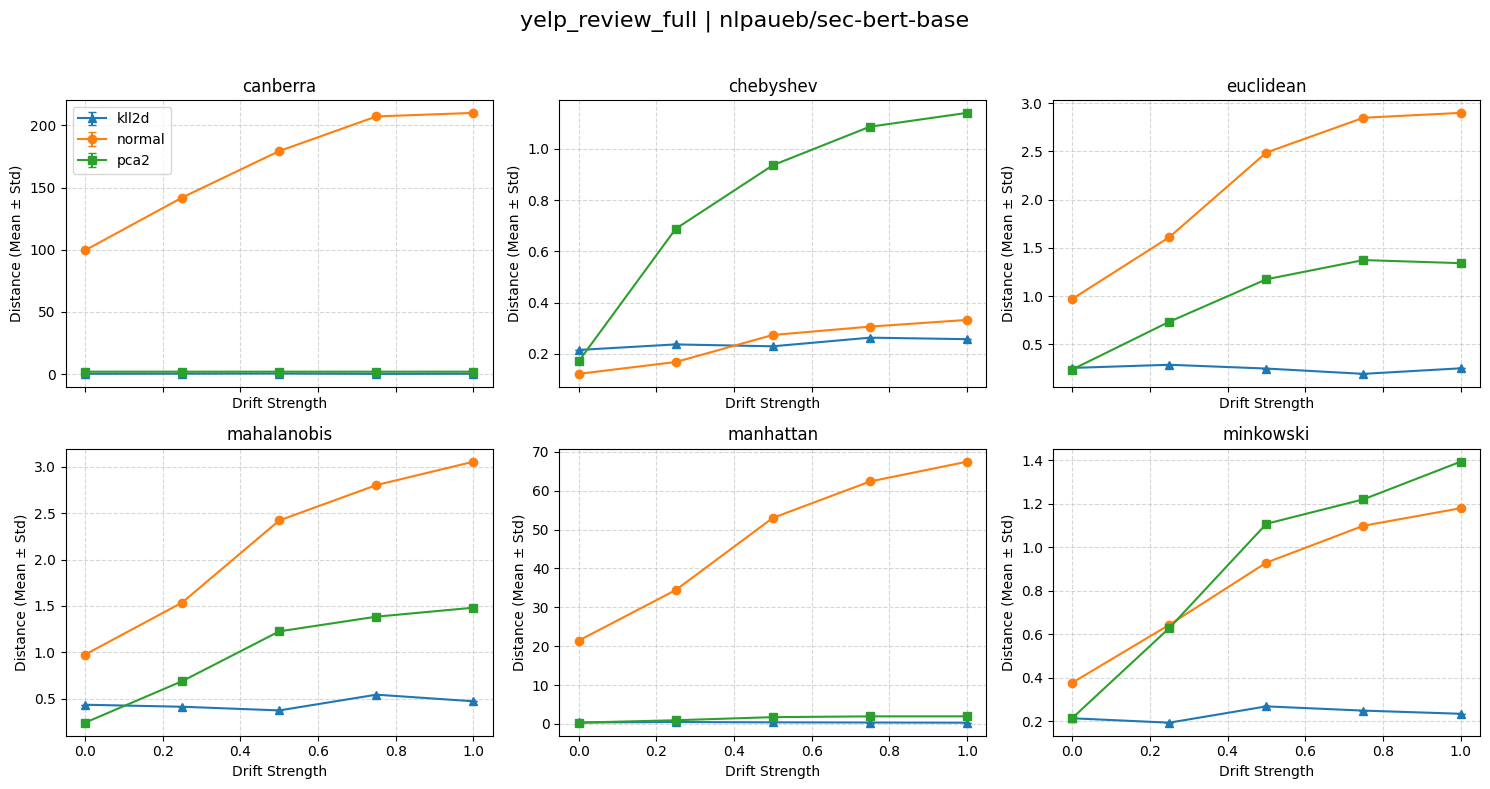

Saved figure: results_multidataset/yelp_review_full_nlpaueb_sec-bert-base_distances_errorbars.png


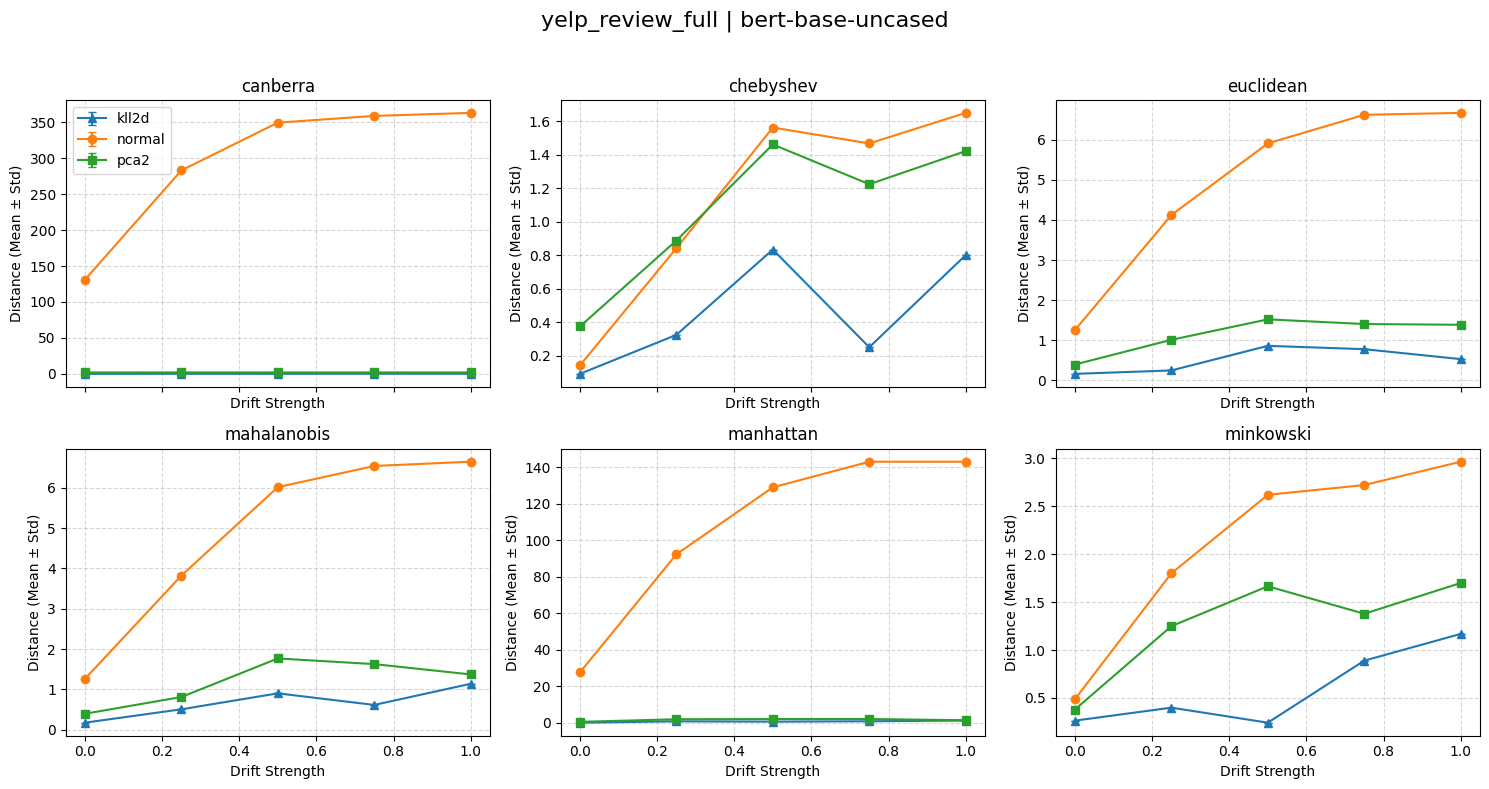

Saved figure: results_multidataset/yelp_review_full_bert-base-uncased_distances_errorbars.png


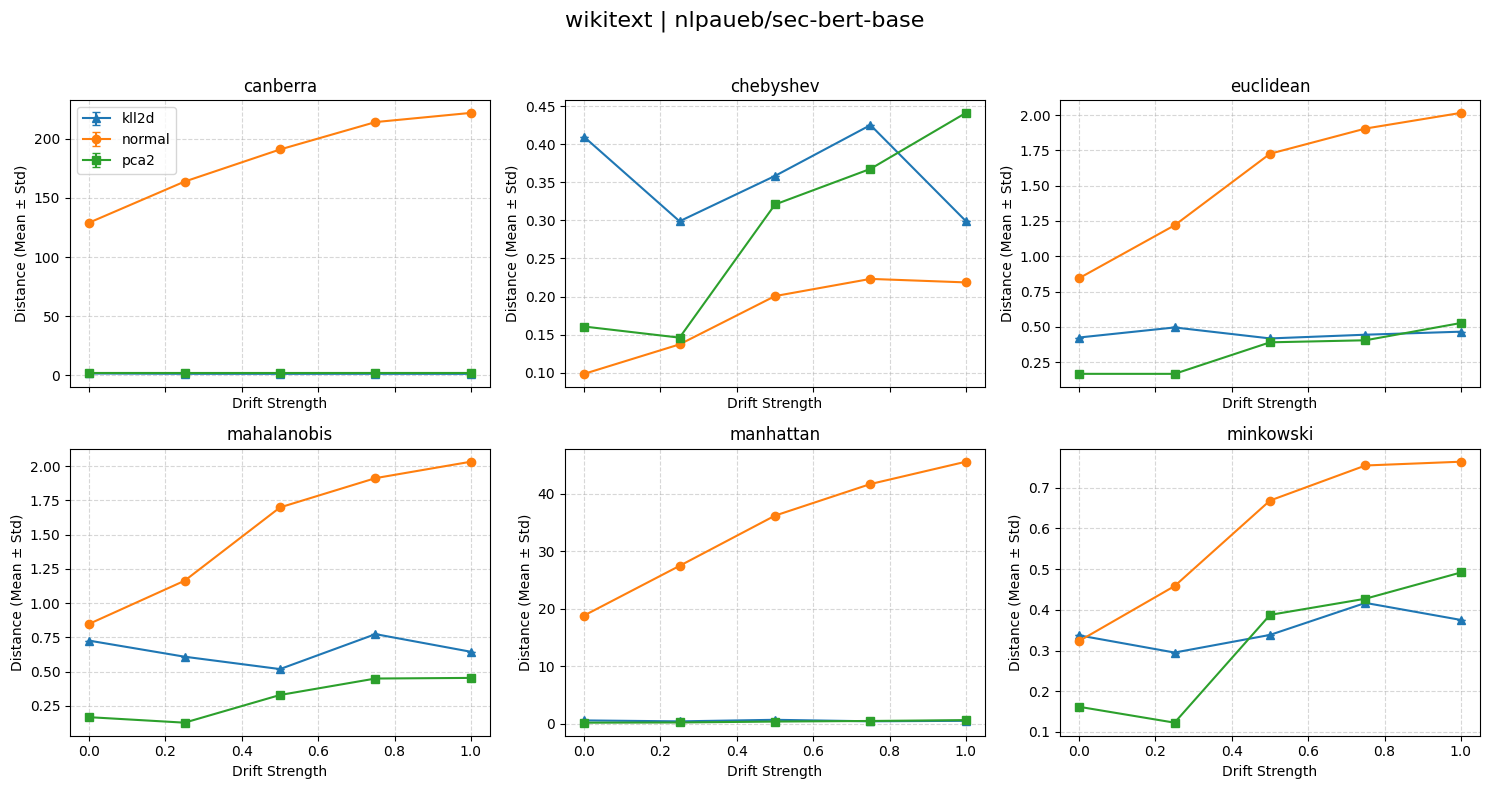

Saved figure: results_multidataset/wikitext_nlpaueb_sec-bert-base_distances_errorbars.png


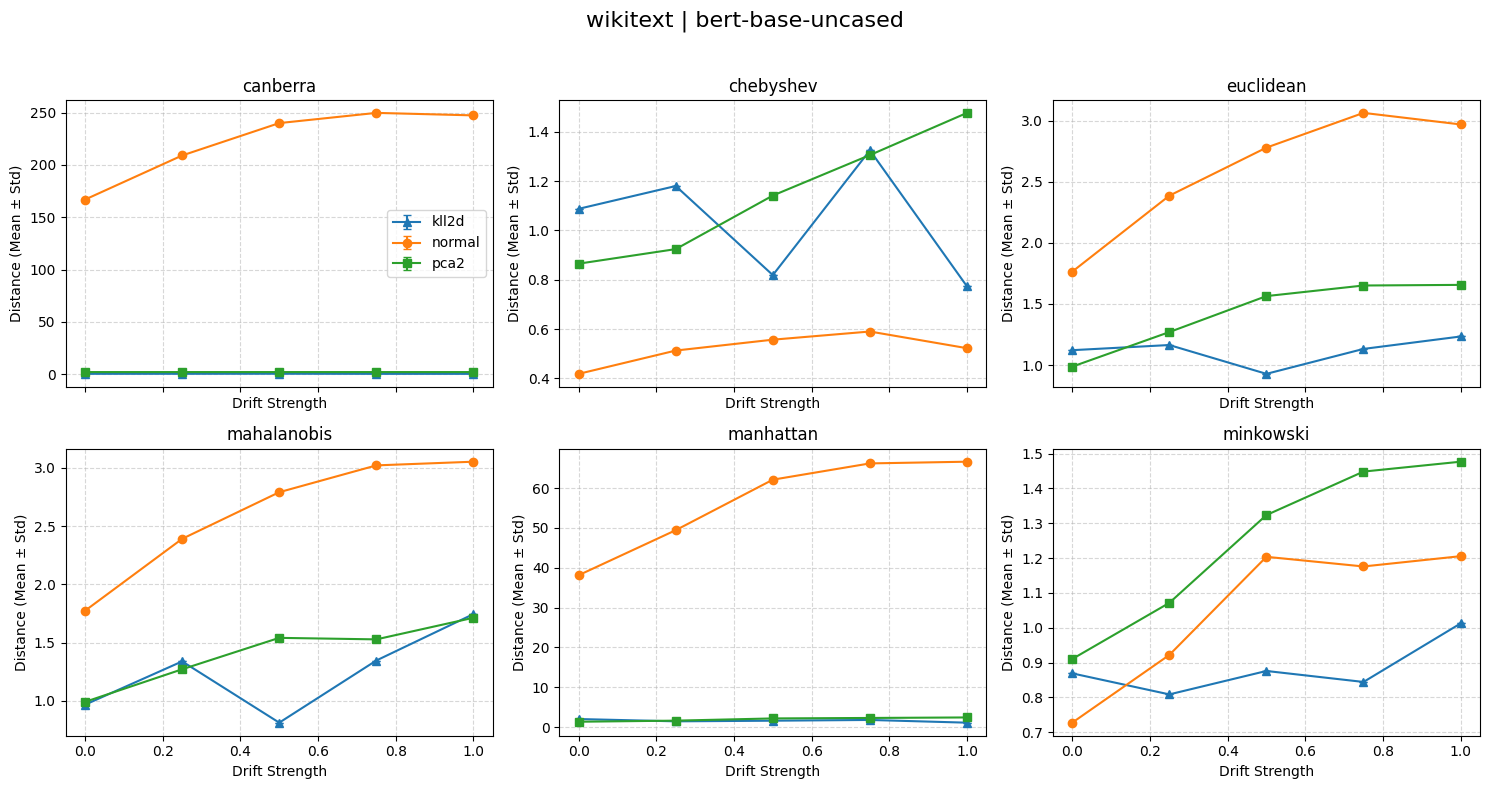

Saved figure: results_multidataset/wikitext_bert-base-uncased_distances_errorbars.png


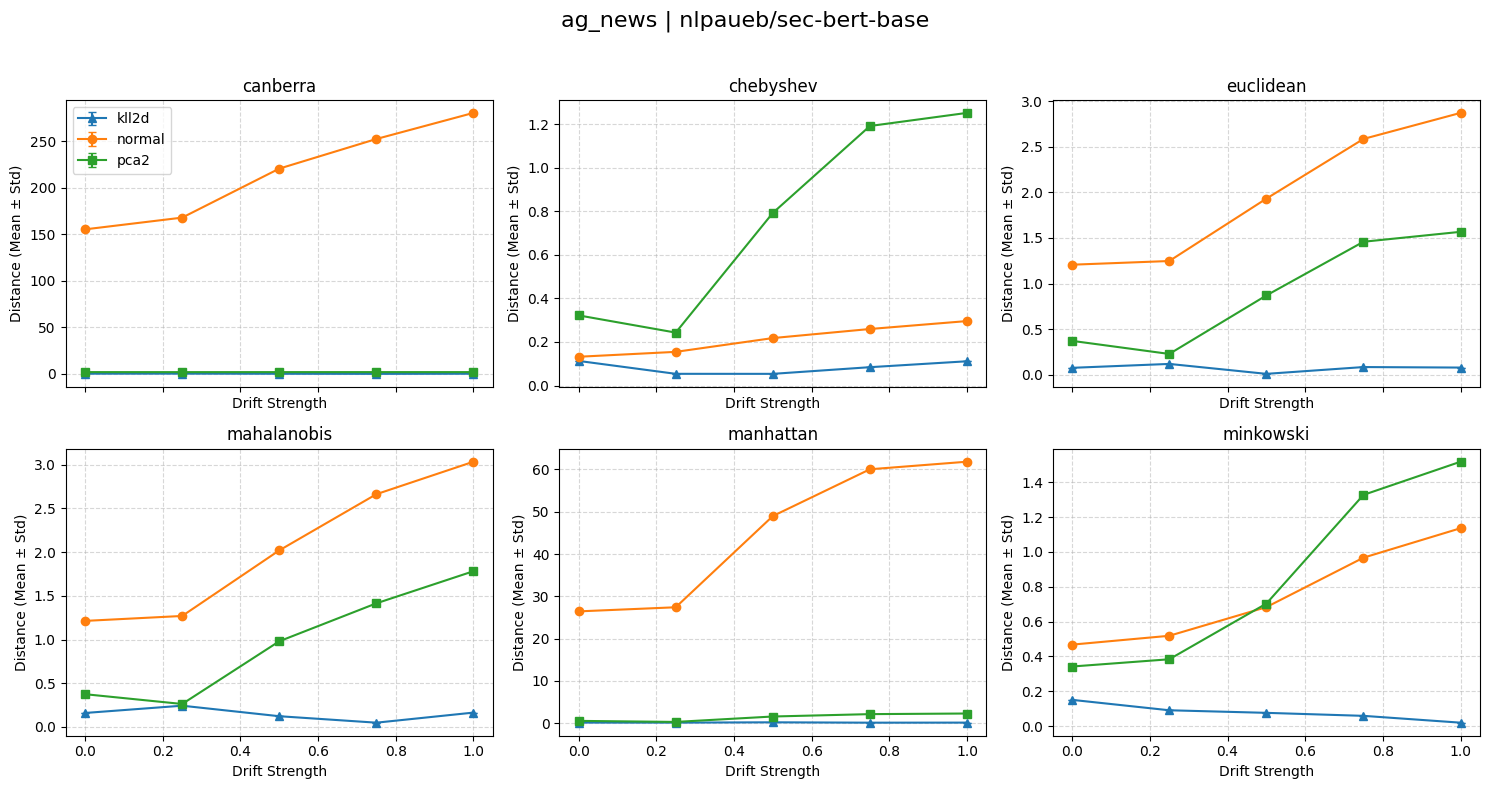

Saved figure: results_multidataset/ag_news_nlpaueb_sec-bert-base_distances_errorbars.png


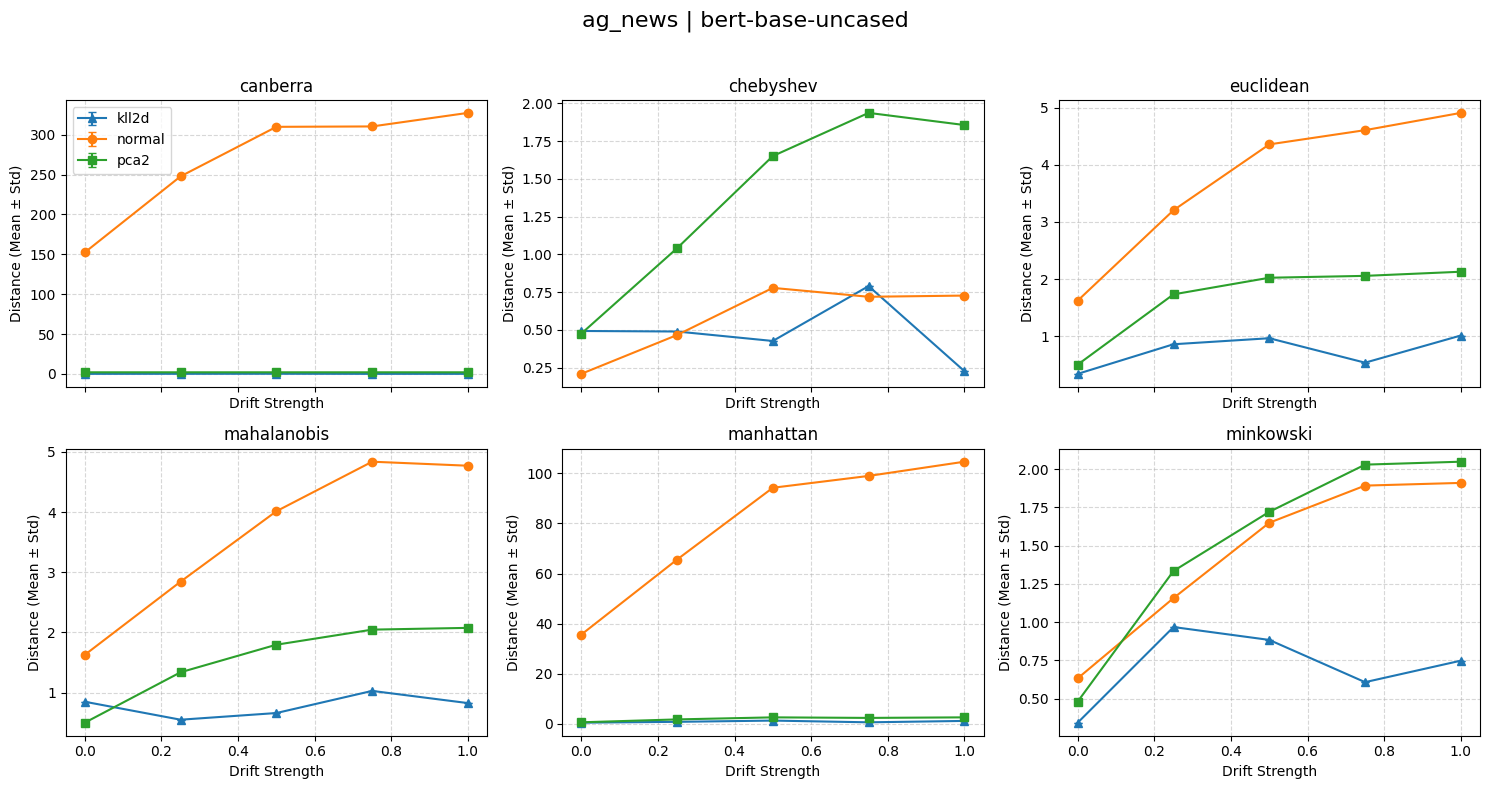

Saved figure: results_multidataset/ag_news_bert-base-uncased_distances_errorbars.png


In [18]:
def plot_distance_with_error_bars(all_results):
    """
    Aggregates across seeds: For each
      (dataset_name, model_name, distance_name, method, drift_strength),
    compute mean + std of final_distance across seeds.
    Then plot error bars for each drift_strength for each method.
    """
    from collections import defaultdict

    aggregator = defaultdict(list)

    # We now use r["method"] instead of pca=True/False
    for (dataset_name, model_name), records in all_results.items():
        for r in records:
            dist_name = r["distance_name"]
            drift_strength = r["drift_strength"]
            method = r["method"]
            final_dist = r["final_similarity"]
            seed = r["seed"]
            key = (dataset_name, model_name, dist_name, method, drift_strength)
            aggregator[key].append(final_dist)

    aggregated_data = []
    for key, dist_values in aggregator.items():
        dataset_name, model_name, dist_name, method, drift_strength = key
        mean_val = np.mean(dist_values)
        std_val = np.std(dist_values)
        aggregated_data.append(
            {
                "dataset_name": dataset_name,
                "model_name": model_name,
                "distance_name": dist_name,
                "method": method,
                "drift_strength": drift_strength,
                "mean_val": mean_val,
                "std_val": std_val,
            }
        )

    grouped = defaultdict(list)
    for row in aggregated_data:
        ds = row["dataset_name"]
        md = row["model_name"]
        grouped[(ds, md)].append(row)

    for (dataset_name, model_name), rows in grouped.items():
        dist_names = sorted(set(r["distance_name"] for r in rows))
        n_dists = len(dist_names)
        n_cols = 3
        n_rows = math.ceil(n_dists / n_cols)
        fig, axs = plt.subplots(
            n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=True
        )
        axs = axs.flatten()
        fig.suptitle(f"{dataset_name} | {model_name}", fontsize=16)

        for i, dist_name in enumerate(dist_names):
            ax = axs[i]
            dist_rows = [r for r in rows if r["distance_name"] == dist_name]
            methods = sorted(set(rr["method"] for rr in dist_rows))
            for method_val in methods:
                subset = [rr for rr in dist_rows if rr["method"] == method_val]
                subset_sorted = sorted(subset, key=lambda x: x["drift_strength"])

                x_vals = [ss["drift_strength"] for ss in subset_sorted]
                y_vals = [ss["mean_val"] for ss in subset_sorted]
                e_vals = [ss["std_val"] for ss in subset_sorted]

                markers = {"normal": "o", "pca2": "s", "kll2d": "^"}
                marker = markers[method_val] if method_val in markers else "o"
                label = f"{method_val}"

                ax.errorbar(
                    x_vals,
                    y_vals,
                    yerr=e_vals,
                    fmt=f"-{marker}",
                    capsize=3,
                    label=label,
                )

            ax.set_title(dist_name)
            ax.set_xlabel("Drift Strength")
            ax.set_ylabel("Distance (Mean ± Std)")
            ax.grid(True, linestyle="--", alpha=0.5)
            if i == 0:
                ax.legend()

        for j in range(i + 1, n_rows * n_cols):
            axs[j].set_visible(False)

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        fname = f"{dataset_name}_{model_name.replace('/', '_')}_distances_errorbars.png"
        save_path = os.path.join(args["output_dir"], fname)
        plt.savefig(save_path, dpi=300)
        plt.show()
        print(f"Saved figure: {save_path}")


plot_distance_with_error_bars(all_results)

In [19]:
all_results

defaultdict(list,
            {('yelp_review_full',
              'nlpaueb/sec-bert-base'): [{'distance_name': 'mahalanobis',
               'drift_strength': 0.0,
               'method': 'normal',
               'final_similarity': np.float64(0.9753117372072347),
               'time_taken': 0.8235929012298584,
               'avg_overhead': np.float64(0.07932388782501221),
               'seed': 0}, {'distance_name': 'mahalanobis',
               'drift_strength': 0.0,
               'method': 'pca2',
               'final_similarity': np.float64(0.2409454954056623),
               'time_taken': 0.5817549228668213,
               'avg_overhead': np.float64(8.594989776611328e-05),
               'seed': 0}, {'distance_name': 'mahalanobis',
               'drift_strength': 0.0,
               'method': 'kll2d',
               'final_similarity': np.float64(0.43433006660245416),
               'time_taken': 0.5881569385528564,
               'avg_overhead': np.float64(0.000470519065856

Saved results to: summary_overhead.csv


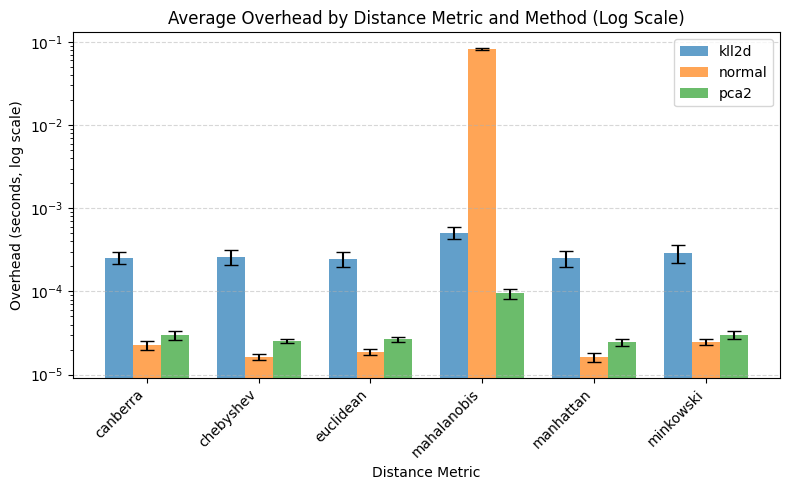

plot done


In [21]:
import pandas as pd


def all_results_to_df(all_results):
    rows = []
    for (dataset_name, model_name), records in all_results.items():
        for r in records:
            row = {
                "Dataset": dataset_name,
                "Model": model_name,
                "distance_name": r["distance_name"],
                "drift_strength": r["drift_strength"],
                "method": r["method"],
                "final_similarity": r["final_similarity"],
                "time_taken": r["time_taken"],
                "avg_overhead": r["avg_overhead"],
                "seed": r["seed"],
            }
            rows.append(row)
    df = pd.DataFrame(rows)
    return df


# Example usage:
df = all_results_to_df(all_results)
# print(df.head())


# 2) Compute summary statistics so each row has a mean and std overhead.
#    Typically you group by ["Dataset", "Model", "distance_name", "method", "drift_strength"].
summary_overhead = (
    df.groupby(["Dataset", "Model", "distance_name", "method", "drift_strength"])
    .agg(mean_overhead=("avg_overhead", "mean"), std_overhead=("avg_overhead", "std"))
    .reset_index()
)

# 3) Call the plotting function, providing the summary DataFrame and the path where to save the CSV.
plot_overhead_bar_aggregated(summary_overhead, "../summary_overhead.csv")